```python
# -*- coding: utf-8 -*-
"""lda_topic_modeling_v2.ipynb

Automatically generated by Colab.

# Тематическое моделирование: LDA (Gensim + MALLET) — v2
**ВКР: Языковые маркеры депрессии и тревожности в социальных сетях**

### Что улучшено по сравнению с v1:
| # | Было | Стало |
|---|------|-------|
| 1 | Маленький список стоп-слов (~20 слов) | Расширенный список (150+ слов) через `pymorphy2` + домен-специфичные |
| 2 | Нет биграмм | Биграммы через `gensim.Phrases` (паническая_атака, не_могу и т.д.) |
| 3 | `no_above=0.85` — слишком мягко | `no_above=0.5` — убираем слова в >50% текстов |
| 4 | `no_below=3` — ловит шум | `no_below=5` — только слова с надёжной частотой |
| 5 | Подбор тем: берём абсолютный максимум CV | Сглаживание + оба критерия: CV и u_mass |
| 6 | passes=10 при подборе, 20 при обучении | passes=15 при подборе, 30 при обучении + iterations=400 |
| 7 | Нет анализа доминирующих тем | Dominant topic per document + распределение по классам |
| 8 | Нет перекрёстного сравнения тем | Матрица пересечений топ-слов между depression/anxiety |
| 9 | pyLDAvis с mds='mmds' | pyLDAvis с mds='pcoa' (более стабильный для рус. текстов) |
| 10 | Нет оценки topic diversity | Добавлена метрика Topic Diversity (уникальность лексики тем) |
"""

In [1]:
!pip install scipy==1.11.2
!pip install --upgrade gensim==3.8.2   # gensim нужной версии
!pip install pyLDAvis==3.4.1

In [4]:
# 0. Установка зависимостей

import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
import gensim
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
from gensim.models.wrappers import LdaMallet
from gensim.models import Phrases
from gensim.models.phrases import Phraser

print(f'Gensim version: {gensim.__version__}')
print('Готово ✓')

Gensim version: 3.8.1
Готово ✓


In [9]:
# 1. Загрузка текстов

# ── ПОМЕНЯЙ НА СВОЙ ПУТЬ ─────────────────────────────────────────────────
LABELED_DIR = Path('/content/drive/MyDrive/SFU 4/VKR/3. labeling/Словарная разметка/(FOR USE) После удаления одинаковых/labeled_clean')
SAVE_DIR    = Path('/content/drive/MyDrive/SFU 4/VKR/7. LDA')
# ─────────────────────────────────────────────────────────────────────────

SAVE_DIR.mkdir(exist_ok=True)
MIN_TOKENS = 5  # минимальная длина текста после очистки

def load_class(label):
    """Загружает .txt файлы одного класса, возвращает список списков токенов."""
    sentences = []
    folder = LABELED_DIR / label
    for fpath in sorted(folder.glob('*.txt')):
        try:
            text = fpath.read_text(encoding='utf-8').strip()
            text = re.sub(r'[^а-яА-ЯёЁ\s]', ' ', text)
            text = re.sub(r'\s+', ' ', text).strip()
            tokens = [t for t in text.lower().split() if t.isalpha() and len(t) > 2]
            if len(tokens) >= MIN_TOKENS:
                sentences.append(tokens)
        except Exception:
            pass
    return sentences

print('Загружаем тексты...')
texts_dep = load_class('depression')
texts_anx = load_class('anxiety')
texts_neu = load_class('neutral')

print(f'depression: {len(texts_dep)} текстов')
print(f'anxiety:    {len(texts_anx)} текстов')
print(f'neutral:    {len(texts_neu)} текстов')

Загружаем тексты...
depression: 1911 текстов
anxiety:    601 текстов
neutral:    3801 текстов


In [10]:
# 2. Расширенная очистка стоп-слов

"""
**Улучшение #1:** Оригинальный список содержал ~20 слов. Здесь используется 4 слоя фильтрации:
- Служебные части речи (местоимения, союзы, предлоги, частицы)
- Высокочастотные глаголы общего значения (знать, говорить, хотеть...)
- Доменно-нейтральные слова, которые встречаются во всех 3 классах одинаково
- Слова-артефакты социальных сетей (бот, репост, ссылка...)

> ⚠️ **Зачем это важно:** слова типа `свой`, `другой`, `какой`, `знать` занимали топ-позиции во всех темах всех классов — они не несут диагностической ценности и "замусоривают" темы.
"""

# ── РАСШИРЕННЫЙ СПИСОК СТОП-СЛОВ ─────────────────────────────────────────

STOP_WORDS = {
    # Местоимения
    'это', 'этот', 'эта', 'эти', 'этом', 'этим', 'этого', 'этой', 'этому',
    'который', 'которая', 'которое', 'которые', 'которых', 'которому', 'которой', 'которым', 'которыми',
    'свой', 'своя', 'своё', 'свои', 'своего', 'своей', 'своему', 'своих', 'своим', 'своими',
    'мой', 'моя', 'моё', 'мои', 'моего', 'моей', 'моих', 'моим',
    'твой', 'твоя', 'твоё', 'твои', 'твоего', 'твоей', 'твоих', 'твоим',
    'наш', 'наша', 'наше', 'наши', 'нашего', 'нашей', 'нашим', 'нашими',
    'ваш', 'ваша', 'ваше', 'ваши', 'вашего', 'вашей', 'вашим',
    'тот', 'та', 'тем', 'того', 'той', 'тех', 'теми',
    'сам', 'сама', 'само', 'сами', 'самого', 'самой', 'самим', 'самому',
    'себя', 'себе', 'собой', 'собою',
    'кто', 'что', 'чего', 'чему', 'чем', 'кого', 'кому', 'кем',
    'никто', 'ничто', 'никого', 'ничего', 'никому', 'ничему',
    'весь', 'вся', 'всё', 'все', 'всего', 'всей', 'всем', 'всеми', 'всех', 'всему',
    'другой', 'другая', 'другое', 'другие', 'другого', 'другой', 'другим', 'других',
    'любой', 'любая', 'любое', 'любые', 'любого', 'любой', 'любым', 'любых',
    'какой', 'какая', 'какое', 'какие', 'каким', 'каких',
    'такой', 'такая', 'такое', 'такие', 'такого', 'такой', 'таким', 'таких',
    'каждый', 'каждая', 'каждое', 'каждые', 'каждого', 'каждой', 'каждым',
    'самый', 'самая', 'самое', 'самые', 'самого', 'самой', 'самым',
    'один', 'одна', 'одно', 'одни', 'одного', 'одной', 'одним',

    # Вспомогательные глаголы и связки
    'быть', 'есть', 'был', 'была', 'было', 'были', 'буду', 'будет', 'будут', 'будем', 'будете',
    'мочь', 'могу', 'можешь', 'может', 'можем', 'можете', 'могут', 'мог', 'могла', 'могли',
    'стать', 'становиться', 'стал', 'стала', 'стало', 'стали',

    # Высокочастотные нейтральные глаголы
    'знать', 'говорить', 'сказать', 'думать', 'понимать', 'понять', 'хотеть',
    'делать', 'сделать', 'идти', 'пойти', 'начать', 'начинать', 'найти', 'находить',
    'давать', 'дать', 'иметь', 'видеть', 'смотреть', 'писать', 'написать',
    'читать', 'слышать', 'жить',

    # Наречия и частицы
    'очень', 'просто', 'также', 'тоже', 'уже', 'ещё', 'ещe', 'еще', 'опять', 'снова',
    'вообще', 'вроде', 'даже', 'именно', 'только', 'лишь', 'хотя', 'хоть',
    'однако', 'нет', 'нету', 'нельзя', 'можно', 'надо', 'нужно', 'нужный',
    'совсем', 'почти', 'часто', 'иногда', 'всегда', 'никогда', 'потом', 'потому',
    'поэтому', 'значит', 'например', 'вместе', 'сразу', 'сильно', 'особенно',
    'наверное', 'может', 'кажется', 'казаться', 'пока', 'пытаться', 'смочь',
    'либо', 'иметь', 'некоторый', 'любить',

    # Нейтральные существительные, не несущие диагностической ценности
    'человек', 'люди', 'жизнь', 'время', 'день', 'год', 'вопрос', 'вопросы',
    'слово', 'слова', 'ответ', 'результат', 'способ', 'место', 'часть',
    'случай', 'момент', 'пример', 'факт', 'раз', 'тема', 'текст', 'пост',
    'первый', 'второй', 'новый', 'разный', 'несколько', 'много', 'мало',

    # Артефакты соцсетей
    'бот', 'репост', 'ссылка', 'лайк', 'канал', 'группа', 'сообщество',
    'написать', 'читать', 'пост', 'комментарий', 'эфир',

    # Прочие высокочастотные, попавшие в топ тем v1
    'ещё', 'дело', 'ваш', 'твой', 'мой', 'хороший', 'плохой',
    'нормально', 'нормальный', 'правда', 'реально', 'спасибо',
    'сказать', 'рассказать', 'первый', 'новый', 'самый', 'каждый',
    'поэтому', 'потому', 'однако', 'также', 'хотя',
}

def clean_texts(texts, stop_words, min_tokens=5):
    cleaned = []
    for doc in texts:
        filtered = [w for w in doc if w not in stop_words and len(w) > 2]
        if len(filtered) >= min_tokens:
            cleaned.append(filtered)
    return cleaned

print('Очищаем тексты...')
texts_dep_c = clean_texts(texts_dep, STOP_WORDS)
texts_anx_c = clean_texts(texts_anx, STOP_WORDS)
texts_neu_c = clean_texts(texts_neu, STOP_WORDS)

print(f'depression: {len(texts_dep)} → {len(texts_dep_c)} текстов')
print(f'anxiety:    {len(texts_anx)} → {len(texts_anx_c)} текстов')
print(f'neutral:    {len(texts_neu)} → {len(texts_neu_c)} текстов')

Очищаем тексты...
depression: 1911 → 1817 текстов
anxiety:    601 → 575 текстов
neutral:    3801 → 3174 текстов


In [17]:
# 3. Биграммы

from collections import Counter

def build_bigrams_manual(texts, min_count=3):
    # Собираем все пары слов
    all_pairs = []
    for doc in texts:
        for i in range(len(doc) - 1):
            all_pairs.append((doc[i], doc[i+1]))

    # Считаем частоты пар
    pair_counts = Counter(all_pairs)

    # Оставляем только пары, встречающиеся min_count+ раз
    frequent_pairs = {pair: count for pair, count in pair_counts.items() if count >= min_count}

    print(f"Найдено частых пар: {len(frequent_pairs)}")

    # Создаем словарь для замены
    replacement_map = {}
    for (w1, w2), count in list(frequent_pairs.items())[:30]:  # берем топ-30
        bigram = f"{w1}_{w2}"
        replacement_map[(w1, w2)] = bigram
        print(f"  {w1}_{w2}: {count}")

    # Применяем замены к текстам
    texts_with_bigrams = []
    for doc in texts:
        new_doc = []
        i = 0
        while i < len(doc):
            if i < len(doc) - 1 and (doc[i], doc[i+1]) in replacement_map:
                new_doc.append(replacement_map[(doc[i], doc[i+1])])
                i += 2
            else:
                new_doc.append(doc[i])
                i += 1
        texts_with_bigrams.append(new_doc)

    return texts_with_bigrams, frequent_pairs

print('Строим биграммы ...')

print('\n--- Depression ---')
texts_dep_b, bigrams_dep = build_bigrams_manual(texts_dep_c, min_count=5)

print('\n--- Anxiety ---')
texts_anx_b, bigrams_anx = build_bigrams_manual(texts_anx_c, min_count=3)

print('\n--- Neutral ---')
texts_neu_b, bigrams_neu = build_bigrams_manual(texts_neu_c, min_count=5)

print(f'\nГотово!')
print(f'Depression: {len(texts_dep_b)} документов, биграмм: {len(bigrams_dep)}')
print(f'Anxiety: {len(texts_anx_b)} документов, биграмм: {len(bigrams_anx)}')
print(f'Neutral: {len(texts_neu_b)} документов, биграмм: {len(bigrams_neu)}')

Строим биграммы ...

--- Depression ---
Найдено частых пар: 518
  сходить_психотерапевт: 6
  назначить_антидепрессант: 7
  головной_боль: 6
  врач_врач: 6
  обратиться_врач: 10
  так_далее: 29
  получить_помощь: 5
  контакт_тело: 5
  тревожный_депрессивный: 17
  депрессивный_расстройство: 23
  отношение_родитель: 8
  депрессия_апатия: 6
  диагноз_ставить: 15
  психический_здоровье: 9
  нервный_срыв: 6
  психиатр_психолог: 28
  похожий_ситуация: 7
  пара_назад: 7
  перестать_общаться: 6
  общаться_друг: 5
  заниматься_спорт: 9
  физический_активность: 12
  мысль_голова: 6
  точный_диагноз: 11
  диагноз_депрессия: 15
  ходить_психолог: 15
  негативный_мысль: 5
  мысль_смерть: 6
  проблема_сон: 16
  тревожный_расстройство: 50

--- Anxiety ---
Найдено частых пар: 511
  рано_поздно: 3
  панический_атака: 95
  постоянный_тревожность: 3
  решить_проблема: 5
  причина_следствие: 3
  стресс_тревога: 4
  тревога_мешать: 3
  обратиться_врач: 4
  дыхательный_упражнение: 7
  стоить_обратиться: 3
  

In [18]:
# 4. Словарь и корпус

"""
- `no_below=3 → 5`: слово должно встречаться хотя бы в 5 документах — снижаем шум от опечаток и редких слов
- `no_above=0.85 → 0.5`: убираем слова, встречающиеся в >50% документов — они слишком общие и не помогают разделить темы

"""

def prepare_corpus(texts, no_below=5, no_above=0.5, keep_n=None):
    """
    no_below : слово должно встречаться минимум в N документах
    no_above : слово не должно встречаться более чем в X% документов
    keep_n   : оставить только топ-N самых частых слов (None = все)
    """
    dictionary = corpora.Dictionary(texts)
    original_size = len(dictionary)
    dictionary.filter_extremes(no_below=no_below, no_above=no_above, keep_n=keep_n)
    corpus = [dictionary.doc2bow(text) for text in texts]
    print(f'  Словарь: {original_size} → {len(dictionary)} слов (после фильтрации)')
    print(f'  Корпус:  {len(corpus)} документов')
    # Считаем пустые документы
    empty = sum(1 for doc in corpus if len(doc) == 0)
    if empty > 0:
        print(f'  ⚠️  Пустых документов: {empty} — они будут проигнорированы моделью')
    return dictionary, corpus

print('Готовим корпусы...')
print('depression:')
dict_dep, corp_dep = prepare_corpus(texts_dep_b)
print('anxiety:')
dict_anx, corp_anx = prepare_corpus(texts_anx_b)
print('neutral:')
dict_neu, corp_neu = prepare_corpus(texts_neu_b)

Готовим корпусы...
depression:
  Словарь: 12257 → 2900 слов (после фильтрации)
  Корпус:  1817 документов
anxiety:
  Словарь: 7666 → 1438 слов (после фильтрации)
  Корпус:  575 документов
neutral:
  Словарь: 13090 → 2616 слов (после фильтрации)
  Корпус:  3174 документов
  ⚠️  Пустых документов: 11 — они будут проигнорированы моделью


Подбираем число тем для depression...


Подбор числа тем:   0%|          | 0/13 [00:00<?, ?it/s]

Подбираем число тем для anxiety...


Подбор числа тем:   0%|          | 0/13 [00:00<?, ?it/s]

Подбираем число тем для neutral...


Подбор числа тем:   0%|          | 0/13 [00:00<?, ?it/s]

depression: оптимум = 6 тем  |  CV=0.3477
anxiety: оптимум = 3 тем  |  CV=0.2879
neutral: оптимум = 13 тем  |  CV=0.3235


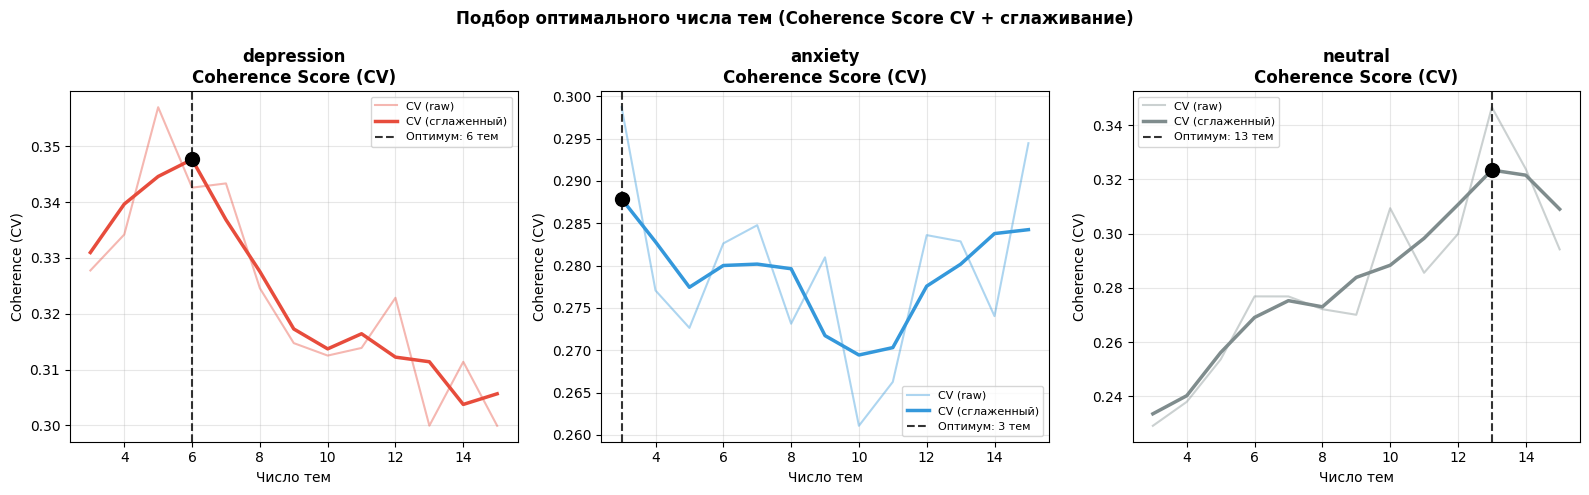


Оптимальное число тем: {'depression': 6, 'anxiety': 3, 'neutral': 13}


In [19]:
# 5. Подбор оптимального числа тем

"""
- `passes=15` при подборе (было 10) — более стабильные оценки
- Сглаживание скользящим средним (окно=3) перед выбором максимума
- Дополнительно считается `u_mass` (другая метрика когерентности): если оба критерия указывают на одно число — это более надёжный выбор
"""

def smooth(values, window=3):
    """Скользящее среднее для сглаживания графика coherence."""
    if len(values) < window:
        return values
    result = []
    for i in range(len(values)):
        start = max(0, i - window // 2)
        end   = min(len(values), i + window // 2 + 1)
        result.append(np.mean(values[start:end]))
    return result


def compute_coherence_values(texts, dictionary, corpus,
                              topic_range=range(3, 16), passes=15):
    """Возвращает CV и u_mass для каждого числа тем."""
    cv_values, um_values = [], []
    for n_topics in tqdm(topic_range, desc='Подбор числа тем'):
        model = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=n_topics,
            passes=passes,
            iterations=200,   # ← было 100 (дефолт)
            random_state=42,
            alpha='auto',
            eta='auto'
        )
        cv = CoherenceModel(model=model, texts=texts,
                            dictionary=dictionary, coherence='c_v').get_coherence()
        um = CoherenceModel(model=model, corpus=corpus,
                            dictionary=dictionary, coherence='u_mass').get_coherence()
        cv_values.append(cv)
        um_values.append(um)
    return cv_values, um_values


TOPIC_RANGE = range(3, 16)

print('Подбираем число тем для depression...')
cv_dep, um_dep = compute_coherence_values(texts_dep_b, dict_dep, corp_dep, TOPIC_RANGE)
print('Подбираем число тем для anxiety...')
cv_anx, um_anx = compute_coherence_values(texts_anx_b, dict_anx, corp_anx, TOPIC_RANGE)
print('Подбираем число тем для neutral...')
cv_neu, um_neu = compute_coherence_values(texts_neu_b, dict_neu, corp_neu, TOPIC_RANGE)

# Визуализация + выбор оптимума со сглаживанием
COLORS = {'depression': '#e74c3c', 'anxiety': '#3498db', 'neutral': '#7f8c8d'}
topics_list = list(TOPIC_RANGE)
optimal_topics = {}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (label, cv, um) in zip(axes, [
    ('depression', cv_dep, um_dep),
    ('anxiety',    cv_anx, um_anx),
    ('neutral',    cv_neu, um_neu),
]):
    # Сглаженный CV для выбора оптимума
    cv_smooth = smooth(cv, window=3)
    best_n = topics_list[cv_smooth.index(max(cv_smooth))]
    optimal_topics[label] = best_n

    color = COLORS[label]
    ax.plot(topics_list, cv, color=color, lw=1.5, alpha=0.4, label='CV (raw)')
    ax.plot(topics_list, cv_smooth, color=color, lw=2.5, label='CV (сглаженный)')
    ax.axvline(best_n, color='black', ls='--', alpha=0.8,
               label=f'Оптимум: {best_n} тем')
    ax.scatter([best_n], [cv_smooth[topics_list.index(best_n)]],
               color='black', s=100, zorder=5)

    ax.set_title(f'{label}\nCoherence Score (CV)', fontweight='bold')
    ax.set_xlabel('Число тем')
    ax.set_ylabel('Coherence (CV)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    print(f'{label}: оптимум = {best_n} тем  |  CV={max(cv_smooth):.4f}')

plt.suptitle('Подбор оптимального числа тем (Coherence Score CV + сглаживание)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'coherence_scores_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nОптимальное число тем: {optimal_topics}')

In [20]:
# 6. Обучение финальных моделей Gensim LDA

"""
**Улучшение #6:** В v1 `passes=20`. Здесь `passes=30, iterations=400` — модель сходится лучше, темы стабильнее.
"""

PASSES     = 30    # было 20
ITERATIONS = 400   # было ~100 (дефолт)

def train_lda(corpus, dictionary, num_topics, label):
    print(f'  Обучаем {label} ({num_topics} тем)...')
    model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        passes=PASSES,
        iterations=ITERATIONS,
        random_state=42,
        alpha='auto',
        eta='auto',
        eval_every=None  # отключаем промежуточную оценку — ускоряет обучение
    )
    # Coherence финальной модели
    cv = CoherenceModel(model=model, texts=texts_dep_b if 'dep' in label else
                        (texts_anx_b if 'anx' in label else texts_neu_b),
                        dictionary=dictionary, coherence='c_v').get_coherence()
    print(f'  ✓ {label}: {num_topics} тем, Coherence CV = {cv:.4f}')
    return model

print('Обучаем Gensim LDA...')
lda_dep = train_lda(corp_dep, dict_dep, optimal_topics['depression'], 'depression_dep')
lda_anx = train_lda(corp_anx, dict_anx, optimal_topics['anxiety'],    'anxiety_anx')
lda_neu = train_lda(corp_neu, dict_neu, optimal_topics['neutral'],    'neutral_neu')

# Сохраняем
lda_dep.save(str(SAVE_DIR / 'lda_depression_v2.model'))
lda_anx.save(str(SAVE_DIR / 'lda_anxiety_v2.model'))
lda_neu.save(str(SAVE_DIR / 'lda_neutral_v2.model'))
print('\nМодели сохранены ✓')

Обучаем Gensim LDA...
  Обучаем depression_dep (6 тем)...
  ✓ depression_dep: 6 тем, Coherence CV = 0.3722
  Обучаем anxiety_anx (3 тем)...
  ✓ anxiety_anx: 3 тем, Coherence CV = 0.3016
  Обучаем neutral_neu (13 тем)...
  ✓ neutral_neu: 13 тем, Coherence CV = 0.3086

Модели сохранены ✓


In [21]:
# 7. MALLET LDA

get_ipython().system('wget -q http://mallet.cs.umass.edu/dist/mallet-2.0.8.tar.gz')
get_ipython().system('tar -xzf mallet-2.0.8.tar.gz')
MALLET_PATH = '/content/mallet-2.0.8/bin/mallet'
os.environ['MALLET_HOME'] = '/content/mallet-2.0.8'
print(f'MALLET установлен ✓')

print('Обучаем MALLET LDA...')
mallet_dep = LdaMallet(MALLET_PATH, corpus=corp_dep, id2word=dict_dep,
                       num_topics=optimal_topics['depression'],
                       iterations=2000, random_seed=42)  # было 1000
print('depression ✓')

mallet_anx = LdaMallet(MALLET_PATH, corpus=corp_anx, id2word=dict_anx,
                       num_topics=optimal_topics['anxiety'],
                       iterations=2000, random_seed=42)
print('anxiety ✓')

mallet_neu = LdaMallet(MALLET_PATH, corpus=corp_neu, id2word=dict_neu,
                       num_topics=optimal_topics['neutral'],
                       iterations=2000, random_seed=42)
print('neutral ✓')

# Сравнение Coherence
print('\n══ Сравнение Coherence CV: Gensim vs MALLET ══')
for label, lda_m, mallet_m, texts, dictionary in [
    ('depression', lda_dep, mallet_dep, texts_dep_b, dict_dep),
    ('anxiety',    lda_anx, mallet_anx, texts_anx_b, dict_anx),
    ('neutral',    lda_neu, mallet_neu, texts_neu_b, dict_neu),
]:
    cv_g = CoherenceModel(model=lda_m,    texts=texts, dictionary=dictionary, coherence='c_v').get_coherence()
    cv_m = CoherenceModel(model=mallet_m, texts=texts, dictionary=dictionary, coherence='c_v').get_coherence()
    winner = 'MALLET ✓' if cv_m > cv_g else 'Gensim ✓'
    print(f'  {label:12s}: Gensim={cv_g:.4f} | MALLET={cv_m:.4f} → {winner}')

MALLET установлен ✓
Обучаем MALLET LDA...
depression ✓
anxiety ✓
neutral ✓

══ Сравнение Coherence CV: Gensim vs MALLET ══
  depression  : Gensim=0.3722 | MALLET=0.3597 → Gensim ✓
  anxiety     : Gensim=0.3016 | MALLET=0.3059 → MALLET ✓
  neutral     : Gensim=0.3086 | MALLET=0.3159 → MALLET ✓


In [22]:
# 8. Topic Diversity

"""
Метрика Topic Diversity (TD) — доля уникальных слов среди топ-N слов всех тем. TD=1.0 — все слова уникальны (темы не пересекаются). TD<0.5 — темы сильно перекрываются.

Это позволяет объективно оценить, насколько хорошо модель разделила темы.
"""

def topic_diversity(model, topn=10):
    """Topic Diversity: доля уникальных слов среди топ-N слов всех тем."""
    all_words = []
    for i, topic in model.show_topics(num_topics=-1, num_words=topn, formatted=False):
        all_words.extend([w for w, _ in topic])
    unique = len(set(all_words))
    total  = len(all_words)
    return unique / total

print('Topic Diversity (топ-10 слов, Gensim LDA):')
for label, model in [('depression', lda_dep), ('anxiety', lda_anx), ('neutral', lda_neu)]:
    td = topic_diversity(model, topn=10)
    quality = '✓ хорошо' if td >= 0.6 else ('⚠️ приемлемо' if td >= 0.4 else '✗ темы перекрываются')
    print(f'  {label:12s}: TD = {td:.3f}  {quality}')

print('\nTopic Diversity (топ-10 слов, MALLET LDA):')
for label, model in [('depression', mallet_dep), ('anxiety', mallet_anx), ('neutral', mallet_neu)]:
    td = topic_diversity(model, topn=10)
    quality = '✓ хорошо' if td >= 0.6 else ('⚠️ приемлемо' if td >= 0.4 else '✗ темы перекрываются')
    print(f'  {label:12s}: TD = {td:.3f}  {quality}')

Topic Diversity (топ-10 слов, Gensim LDA):
  depression  : TD = 0.717  ✓ хорошо
  anxiety     : TD = 0.767  ✓ хорошо
  neutral     : TD = 0.838  ✓ хорошо

Topic Diversity (топ-10 слов, MALLET LDA):
  depression  : TD = 0.917  ✓ хорошо
  anxiety     : TD = 1.000  ✓ хорошо
  neutral     : TD = 0.992  ✓ хорошо


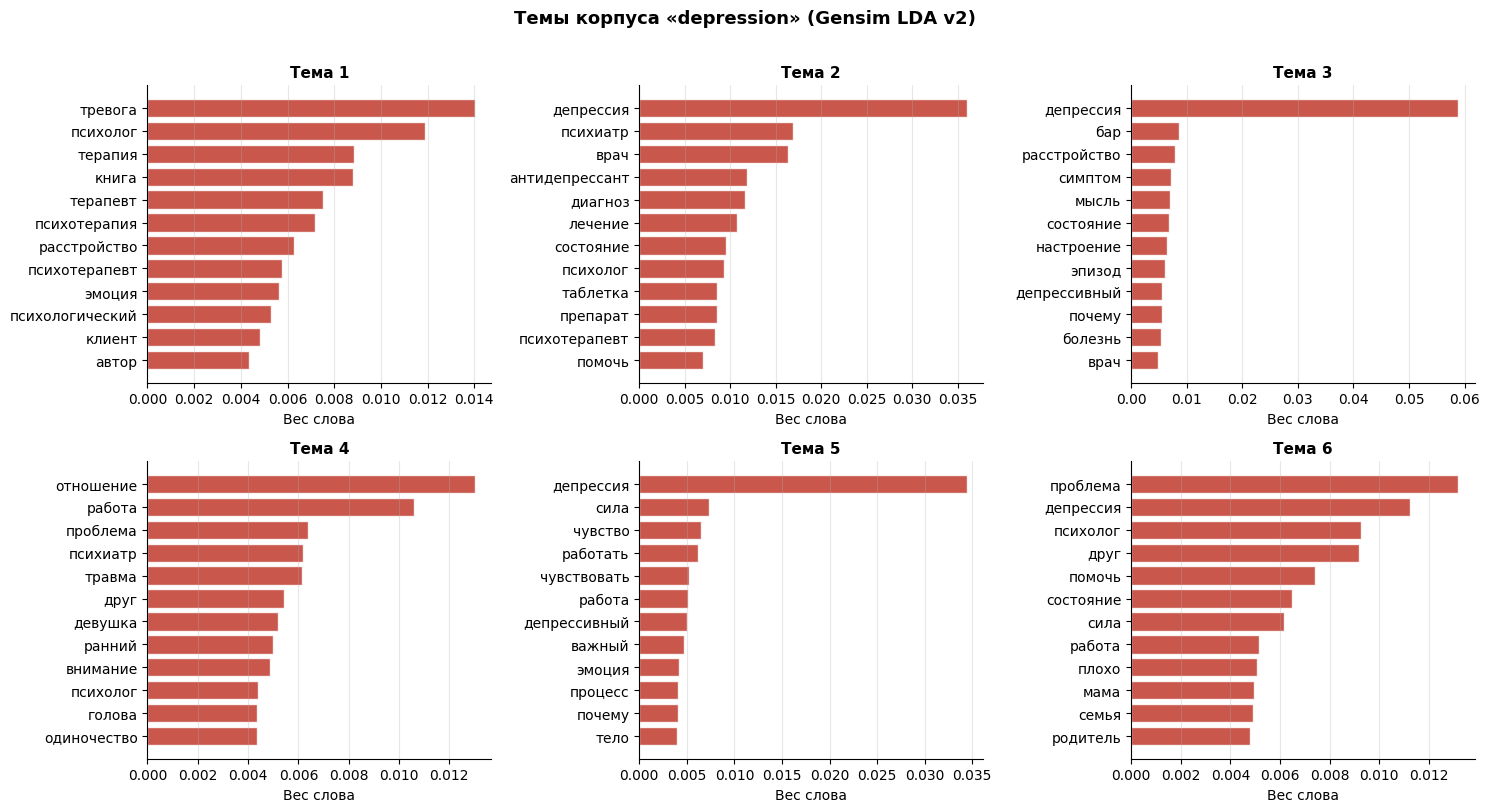

Сохранено: topics_depression_v2.png


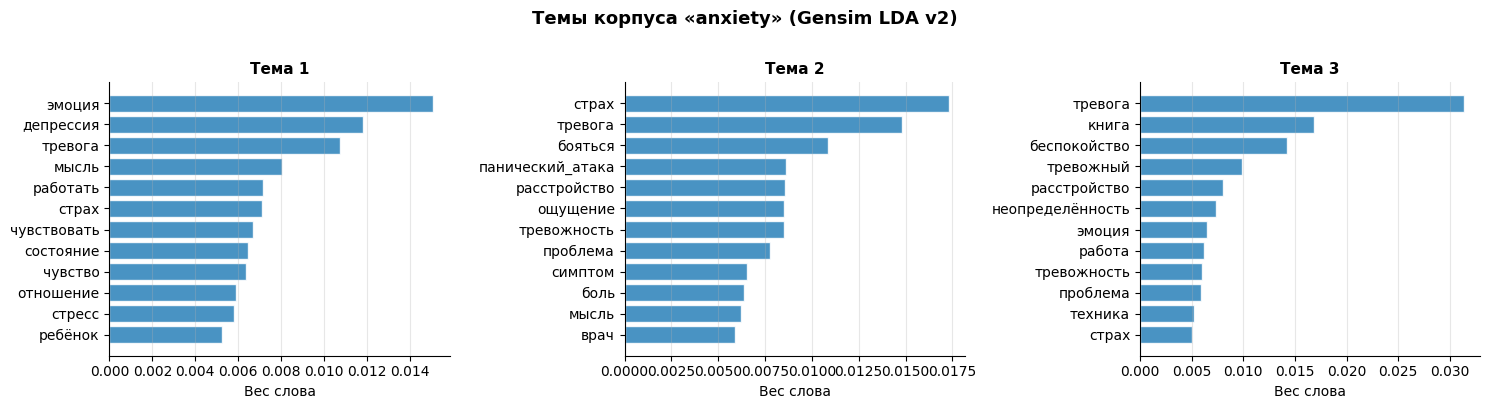

Сохранено: topics_anxiety_v2.png


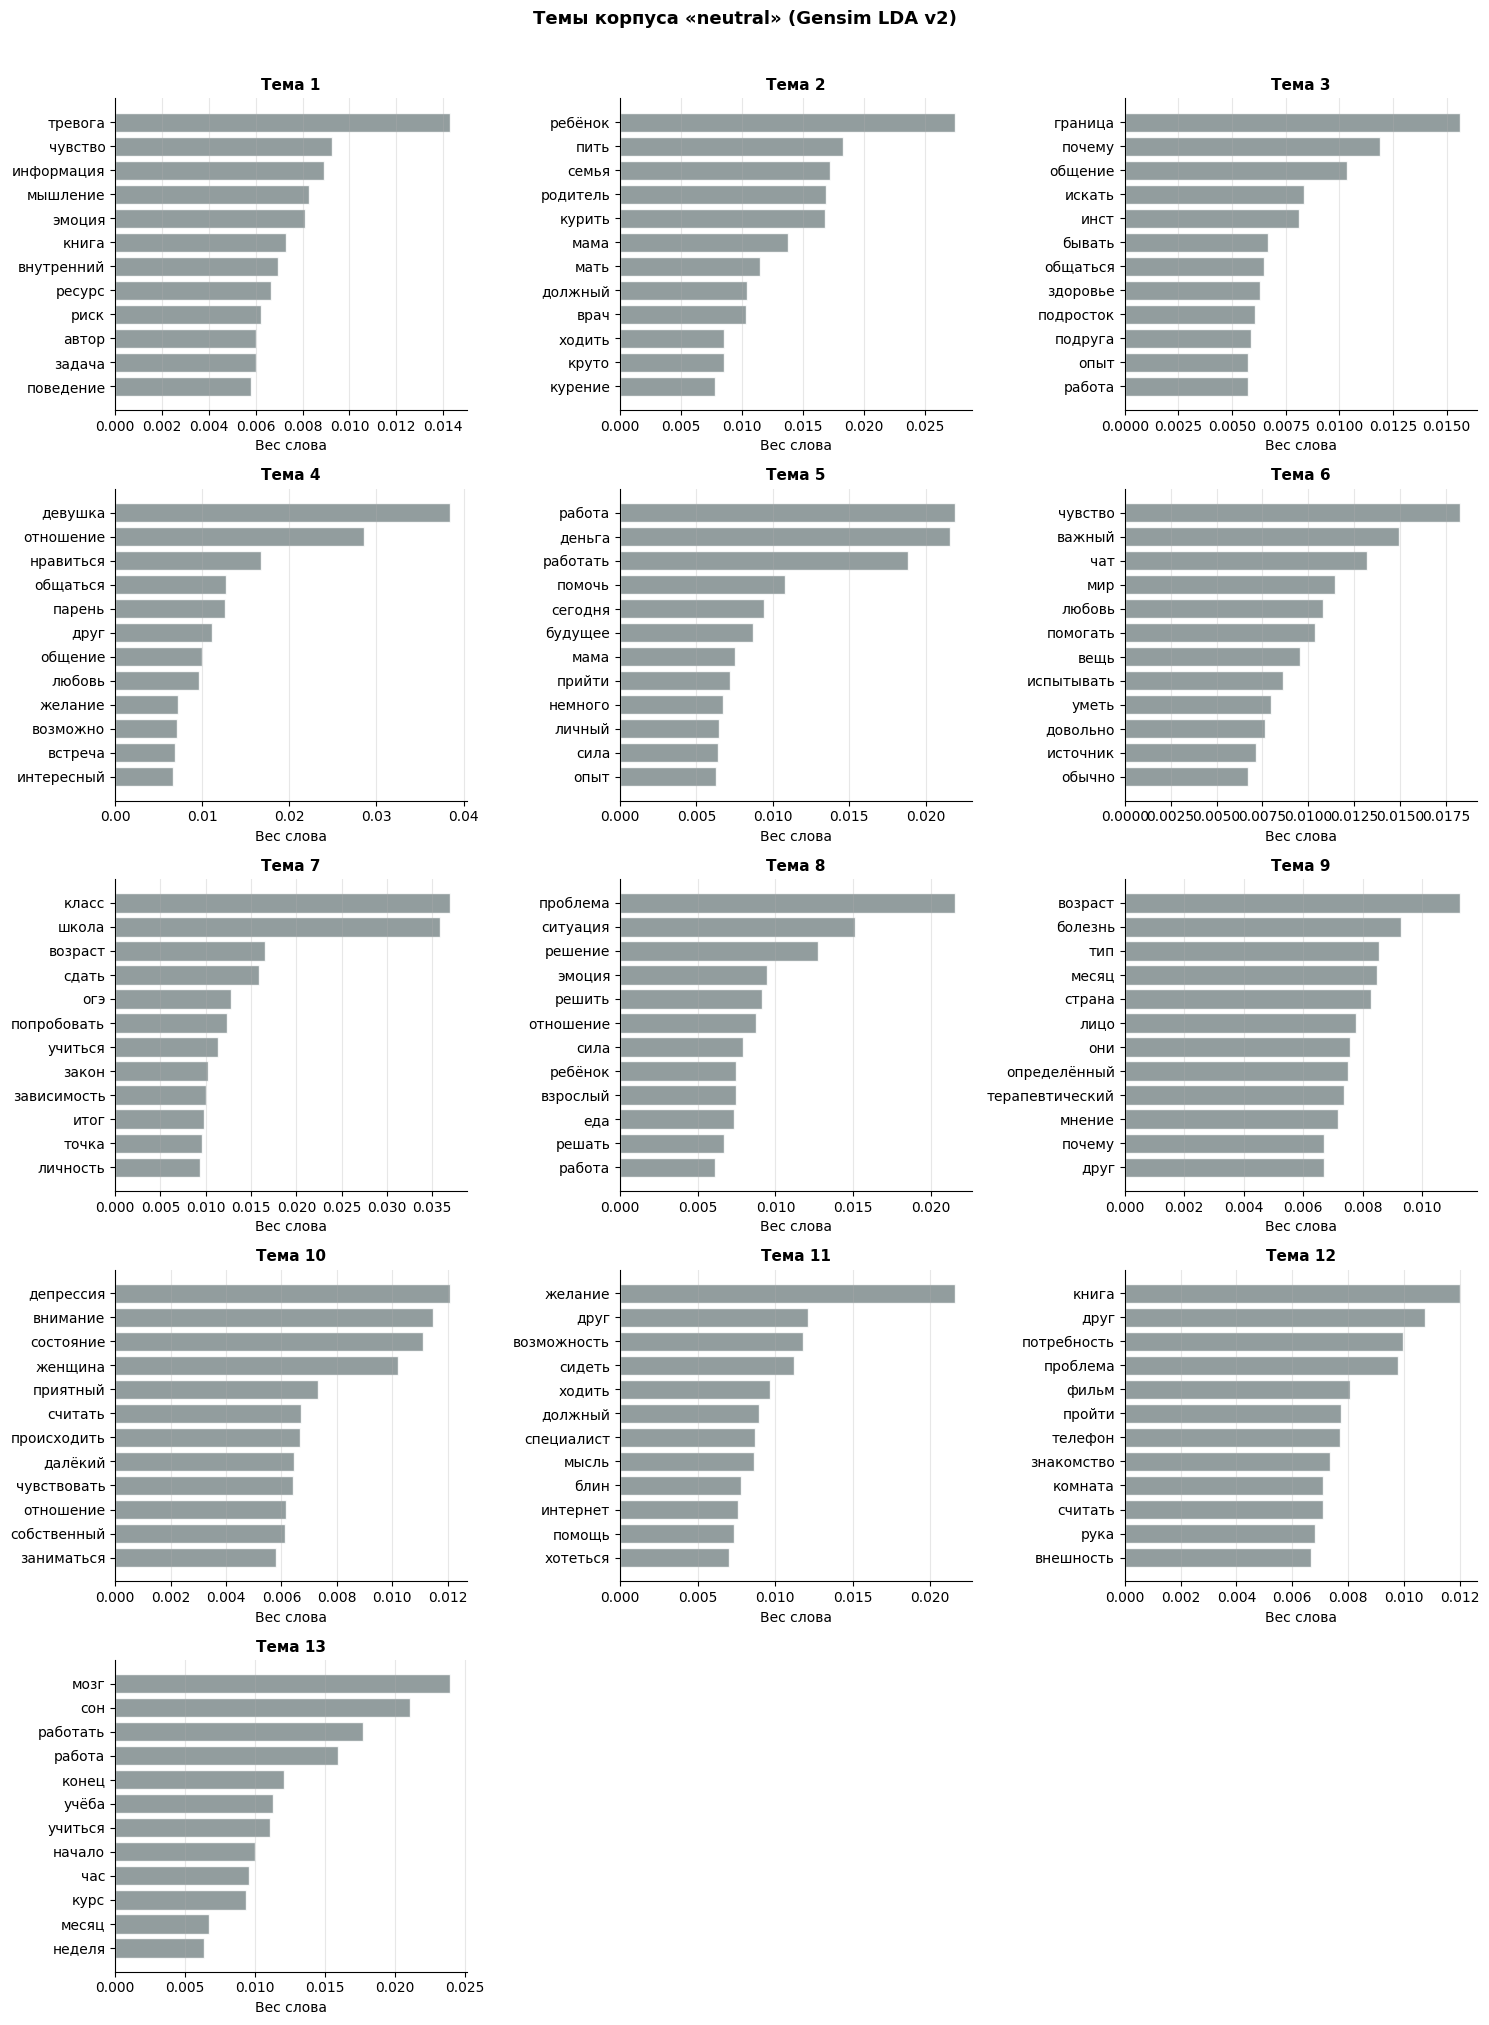

Сохранено: topics_neutral_v2.png


In [23]:
# 9. Визуализация тем — барчарты

def plot_topics(model, label, n_words=12, color='#e74c3c'):
    n_topics = model.num_topics
    cols = min(3, n_topics)
    rows = (n_topics + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
    axes = np.array(axes).flatten()

    for i, topic in model.show_topics(num_topics=-1, num_words=n_words, formatted=False):
        words   = [w for w, _ in topic]
        weights = [p for _, p in topic]
        ax = axes[i]
        bars = ax.barh(range(len(words)), weights, color=color, alpha=0.85, edgecolor='white')
        ax.set_yticks(range(len(words)))
        ax.set_yticklabels(words, fontsize=10)
        ax.invert_yaxis()
        ax.set_title(f'Тема {i+1}', fontweight='bold', fontsize=11)
        ax.set_xlabel('Вес слова')
        ax.grid(axis='x', alpha=0.3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f'Темы корпуса «{label}» (Gensim LDA v2)',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    path = SAVE_DIR / f'topics_{label}_v2.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Сохранено: topics_{label}_v2.png')

plot_topics(lda_dep, 'depression', color='#c0392b')
plot_topics(lda_anx, 'anxiety',    color='#2980b9')
plot_topics(lda_neu, 'neutral',    color='#7f8c8d')

In [24]:
# 10. pyLDAvis

"""
В v1 использовался `mds='mmds'`. Для русскоязычных корпусов `mds='pcoa'` (Principal Coordinates Analysis) даёт более стабильное и читаемое расположение тем.
"""

import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
pyLDAvis.enable_notebook()

for label, model, corpus, dictionary in [
    ('depression', lda_dep, corp_dep, dict_dep),
    ('anxiety',    lda_anx, corp_anx, dict_anx),
    ('neutral',    lda_neu, corp_neu, dict_neu),
]:
    print(f'Строим pyLDAvis для {label}...')
    vis = gensimvis.prepare(
        model, corpus, dictionary,
        sort_topics=False,
        mds='pcoa'   # ← было 'mmds'
    )
    pyLDAvis.save_html(vis, str(SAVE_DIR / f'pyldavis_{label}_v2.html'))
    print(f'  Сохранено: pyldavis_{label}_v2.html')

Строим pyLDAvis для depression...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

  Сохранено: pyldavis_depression_v2.html
Строим pyLDAvis для anxiety...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

  Сохранено: pyldavis_anxiety_v2.html
Строим pyLDAvis для neutral...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

  Сохранено: pyldavis_neutral_v2.html


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

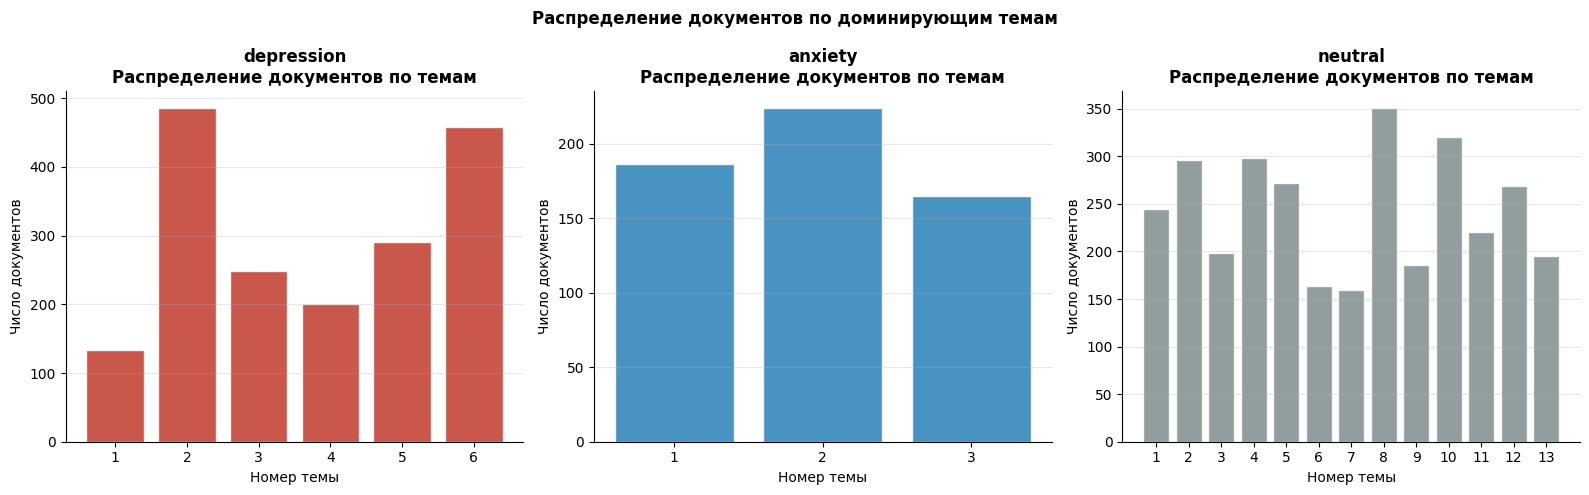


Средняя уверенность в доминирующей теме (чем выше — тем чище темы):
  depression  : 0.794 ± 0.193
  anxiety     : 0.891 ± 0.166
  neutral     : 0.582 ± 0.198


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [25]:
# 11. Доминирующая тема по документам

"""
Для каждого документа определяем тему с наибольшим весом (dominant topic). Это позволяет:
- Посмотреть, как тексты распределяются по темам
- Найти "нетипичные" тексты с низкой уверенностью
- Сравнить тематическое распределение между классами
"""

def get_dominant_topics(model, corpus, texts):
    """Для каждого документа возвращает доминирующую тему и её вес."""
    rows = []
    for i, (bow, tokens) in enumerate(zip(corpus, texts)):
        topic_dist = model.get_document_topics(bow, minimum_probability=0)
        if not topic_dist:
            continue
        dom_topic, dom_prob = max(topic_dist, key=lambda x: x[1])
        top_words = ', '.join([w for w, _ in model.show_topic(dom_topic, topn=5)])
        rows.append({
            'doc_id':       i,
            'dom_topic':    dom_topic + 1,  # 1-based
            'dom_prob':     round(dom_prob, 4),
            'topic_words':  top_words,
            'text_preview': ' '.join(tokens[:10]) + '...'
        })
    return pd.DataFrame(rows)


df_dep = get_dominant_topics(lda_dep, corp_dep, texts_dep_b)
df_anx = get_dominant_topics(lda_anx, corp_anx, texts_anx_b)
df_neu = get_dominant_topics(lda_neu, corp_neu, texts_neu_b)

# Распределение документов по темам
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (label, df, color) in zip(axes, [
    ('depression', df_dep, '#c0392b'),
    ('anxiety',    df_anx, '#2980b9'),
    ('neutral',    df_neu, '#7f8c8d'),
]):
    counts = df['dom_topic'].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(f'{label}\nРаспределение документов по темам', fontweight='bold')
    ax.set_xlabel('Номер темы')
    ax.set_ylabel('Число документов')
    ax.set_xticks(counts.index)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Распределение документов по доминирующим темам', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'dominant_topics_v2.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nСредняя уверенность в доминирующей теме (чем выше — тем чище темы):')
for label, df in [('depression', df_dep), ('anxiety', df_anx), ('neutral', df_neu)]:
    print(f'  {label:12s}: {df["dom_prob"].mean():.3f} ± {df["dom_prob"].std():.3f}')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

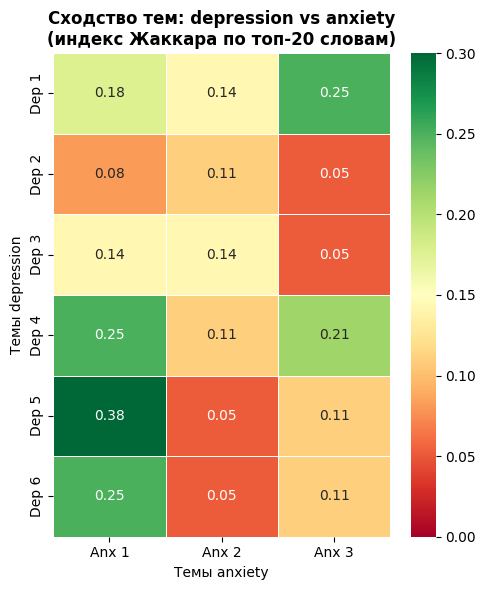


Пересекающиеся слова для наиболее похожих пар тем (Жаккар > 0.05):
  Dep тема 1 ↔ Anx тема 1: J=0.18 | общие слова: ['друг', 'мысль', 'работать', 'страх', 'тревога', 'эмоция']
  Dep тема 1 ↔ Anx тема 2: J=0.14 | общие слова: ['мысль', 'расстройство', 'страх', 'терапия', 'тревога']
  Dep тема 1 ↔ Anx тема 3: J=0.25 | общие слова: ['книга', 'мысль', 'работать', 'расстройство', 'страх', 'терапия', 'тревога', 'эмоция']
  Dep тема 2 ↔ Anx тема 1: J=0.08 | общие слова: ['депрессия', 'причина', 'состояние']
  Dep тема 2 ↔ Anx тема 2: J=0.11 | общие слова: ['врач', 'расстройство', 'симптом', 'терапия']
  Dep тема 2 ↔ Anx тема 3: J=0.05 | общие слова: ['расстройство', 'терапия']
  Dep тема 3 ↔ Anx тема 1: J=0.14 | общие слова: ['депрессия', 'мысль', 'почему', 'состояние', 'чувство']
  Dep тема 3 ↔ Anx тема 2: J=0.14 | общие слова: ['бывать', 'врач', 'мысль', 'расстройство', 'симптом']
  Dep тема 3 ↔ Anx тема 3: J=0.05 | общие слова: ['мысль', 'расстройство']
  Dep тема 4 ↔ Anx тема 1: J=0.25 |

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [26]:
# 12. Матрица пересечений тем: depression vs anxiety

"""
Сравниваем топ-слова тем двух классов — выявляем, какие темы разделяются, а какие пересекаются между депрессией и тревогой. Это важно для ВКР: показывает языковые сходства и различия двух расстройств.
"""

def get_topic_words_set(model, topn=20):
    """Возвращает словарь {номер_темы: множество_слов}."""
    return {
        i + 1: set(w for w, _ in model.show_topic(i, topn=topn))
        for i in range(model.num_topics)
    }

words_dep = get_topic_words_set(lda_dep, topn=20)
words_anx = get_topic_words_set(lda_anx, topn=20)

# Матрица Жаккара: overlap(dep_i, anx_j) = |пересечение| / |объединение|
n_dep = len(words_dep)
n_anx = len(words_anx)
matrix = np.zeros((n_dep, n_anx))

for i, w_dep in words_dep.items():
    for j, w_anx in words_anx.items():
        intersection = w_dep & w_anx
        union = w_dep | w_anx
        matrix[i-1, j-1] = len(intersection) / len(union) if union else 0

fig, ax = plt.subplots(figsize=(max(5, n_anx * 1.5), max(6, n_dep * 0.9)))
sns.heatmap(
    matrix,
    annot=True, fmt='.2f', cmap='RdYlGn',
    xticklabels=[f'Anx {j}' for j in range(1, n_anx+1)],
    yticklabels=[f'Dep {i}' for i in range(1, n_dep+1)],
    vmin=0, vmax=0.3,
    linewidths=0.5, ax=ax
)
ax.set_title('Сходство тем: depression vs anxiety\n(индекс Жаккара по топ-20 словам)',
             fontweight='bold')
ax.set_xlabel('Темы anxiety')
ax.set_ylabel('Темы depression')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'topic_overlap_dep_anx_v2.png', dpi=150, bbox_inches='tight')
plt.show()

# Печатаем пересекающиеся слова для максимально похожих пар тем
print('\nПересекающиеся слова для наиболее похожих пар тем (Жаккар > 0.05):')
for i, w_dep in words_dep.items():
    for j, w_anx in words_anx.items():
        overlap = w_dep & w_anx
        jaccard = len(overlap) / len(w_dep | w_anx)
        if jaccard > 0.05 and overlap:
            print(f'  Dep тема {i} ↔ Anx тема {j}: J={jaccard:.2f} | общие слова: {sorted(overlap)}')


In [27]:
# 13. Сохранение результатов в Excel

import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils import get_column_letter

wb = openpyxl.Workbook()
fill_dep = PatternFill(start_color='FFCCCC', fill_type='solid')
fill_anx = PatternFill(start_color='CCE5FF', fill_type='solid')
fill_neu = PatternFill(start_color='E8E8E8', fill_type='solid')
fills = {'depression': fill_dep, 'anxiety': fill_anx, 'neutral': fill_neu}

for label, gensim_m, mallet_m in [
    ('depression', lda_dep, mallet_dep),
    ('anxiety',    lda_anx, mallet_anx),
    ('neutral',    lda_neu, mallet_neu),
]:
    for sheet_label, model in [(f'{label[:4]}_Gensim', gensim_m),
                                (f'{label[:4]}_MALLET', mallet_m)]:
        ws = wb.create_sheet(title=sheet_label)
        ws.append([f'Темы LDA — {label} ({model.num_topics} тем)  |  v2'])
        ws.cell(1, 1).font = Font(bold=True, size=12)
        ws.append([])
        for i, topic in model.show_topics(num_topics=-1, num_words=20, formatted=False):
            td = topic_diversity(model, topn=10)
            ws.append([f'Тема {i+1}'] + [f'{w} ({p:.4f})' for w, p in topic])
            ws.cell(ws.max_row, 1).font = Font(bold=True)
            ws.cell(ws.max_row, 1).fill = fills[label]
        for col in range(1, 22):
            ws.column_dimensions[get_column_letter(col)].width = 22

# Лист с dominant topics
ws_dt = wb.create_sheet('dominant_topics')
ws_dt.append(['class', 'doc_id', 'dom_topic', 'dom_prob', 'topic_words', 'text_preview'])
ws_dt.cell(1, 1).font = Font(bold=True)
for label, df in [('depression', df_dep), ('anxiety', df_anx), ('neutral', df_neu)]:
    for _, row in df.iterrows():
        ws_dt.append([label, int(row['doc_id']), int(row['dom_topic']),
                      float(row['dom_prob']), row['topic_words'], row['text_preview']])

if 'Sheet' in wb.sheetnames:
    del wb['Sheet']

wb.save(SAVE_DIR / 'lda_topics_all_v2.xlsx')
print(f'Сохранено: lda_topics_all_v2.xlsx')
print(f'Листы: {wb.sheetnames}')


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Сохранено: lda_topics_all_v2.xlsx
Листы: ['depr_Gensim', 'depr_MALLET', 'anxi_Gensim', 'anxi_MALLET', 'neut_Gensim', 'neut_MALLET', 'dominant_topics']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


"""
---
## Итоговая сводка улучшений

| Параметр | v1 | v2 | Эффект |
|----------|----|----|--------|
| Стоп-слова | ~20 слов | 150+ слов | Убраны "мусорные" топ-слова: свой, другой, знать |
| Биграммы | нет | да (min_count=5, threshold=8) | паническая_атака, побочный_эффект в темах |
| no_below | 3 | 5 | Меньше шума от редких слов |
| no_above | 0.85 | 0.5 | Убраны слова, общие для всех текстов |
| passes при подборе | 10 | 15 | Стабильнее оценка coherence |
| iterations | ~100 | 200/400 | Лучшая сходимость модели |
| passes финальной модели | 20 | 30 | Более устойчивые темы |
| Подбор оптимума | abs. max CV | CV со сглаживанием | Не ловим случайные пики |
| pyLDAvis mds | mmds | pcoa | Более стабильная визуализация |
| Анализ документов | нет | dominant topic | Распределение текстов по темам |
| Сравнение классов | нет | матрица Жаккара | Какие темы общие у depression/anxiety |
| Topic Diversity | нет | да | Объективная оценка качества разделения тем |
"""
```